In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

# -----------------------------
# Training data
# -----------------------------

# Input sentences
input_texts = [
    "hello",
    "good morning",
    "thank you",
    "good night"
]

# Output sentences
target_texts = [
    "hola",
    "buenos dias",
    "gracias",
    "buenas noches"
]

# -----------------------------
# Create character vocabulary
# -----------------------------

input_chars = sorted(set("".join(input_texts)))
target_chars = sorted(set("".join(target_texts)))

input_vocab_size = len(input_chars)
target_vocab_size = len(target_chars)

input_char_to_int = {
    char: i for i, char in enumerate(input_chars)
}

target_char_to_int = {
    char: i for i, char in enumerate(target_chars)
}

# -----------------------------
# Convert text to numbers
# -----------------------------

max_input_length = max(len(text) for text in input_texts)
max_target_length = max(len(text) for text in target_texts)

encoder_input_data = np.zeros(
    (len(input_texts), max_input_length, input_vocab_size)
)

decoder_input_data = np.zeros(
    (len(input_texts), max_target_length, target_vocab_size)
)

decoder_target_data = np.zeros(
    (len(input_texts), max_target_length, target_vocab_size)
)

for i, (input_text, target_text) in enumerate(
    zip(input_texts, target_texts)
):

    # Encoder
    for t, char in enumerate(input_text):
        encoder_input_data[
            i, t, input_char_to_int[char]
        ] = 1

    # Decoder
    for t, char in enumerate(target_text):
        decoder_input_data[
            i, t, target_char_to_int[char]
        ] = 1

        # Target is shifted by one timestep
        if t > 0:
            decoder_target_data[
                i, t - 1, target_char_to_int[char]
            ] = 1

# -----------------------------
# Encoder
# -----------------------------

encoder_inputs = Input(
    shape=(None, input_vocab_size)
)

encoder_lstm = LSTM(
    128,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_inputs
)

encoder_states = [state_h, state_c]

# -----------------------------
# Decoder
# -----------------------------

decoder_inputs = Input(
    shape=(None, target_vocab_size)
)

decoder_lstm = LSTM(
    128,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

decoder_dense = Dense(
    target_vocab_size,
    activation="softmax"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

# -----------------------------
# Complete Encoder-Decoder
# -----------------------------

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

# -----------------------------
# Compile
# -----------------------------

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# Train
# -----------------------------

model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=100,
    verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.0577 - loss: 1.6162
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1346 - loss: 1.6037
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1731 - loss: 1.5926
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1923 - loss: 1.5788
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1923 - loss: 1.5627
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1923 - loss: 1.5449
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1923 - loss: 1.5207
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1923 - loss: 1.4921
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1923 - loss: 1.4396
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1538 - loss: 1.3930
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1538 - loss: 1.3801
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1731 - lo

In [2]:
encoder_lstm = LSTM(
    128,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_inputs
)

In [3]:
decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=encoder_states
)

In [4]:
decoder_dense = Dense(
    target_vocab_size,
    activation="softmax"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
Encoder output shape: (1, 10, 128)
Hidden state shape: (1, 128)
Cell state shape: (1, 128)


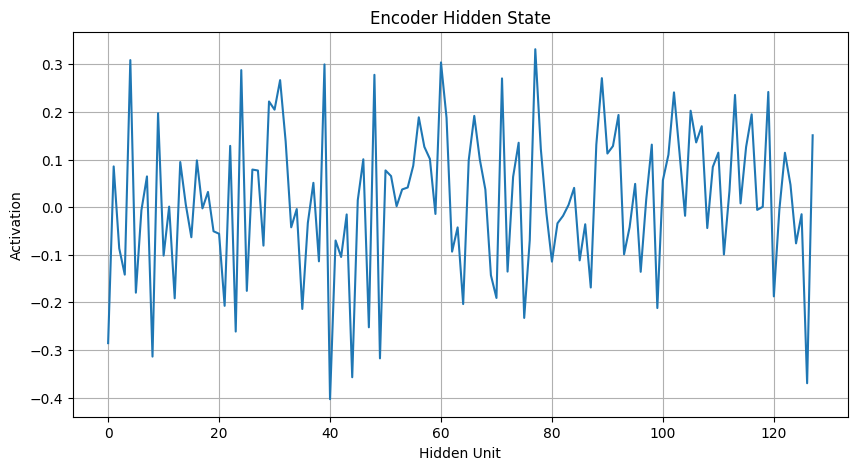

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM
from tensorflow.keras.models import Model

# -----------------------------
# Create sample input
# -----------------------------
X = np.random.random((1, 10, 50))

# -----------------------------
# Encoder
# -----------------------------
encoder_input = Input(shape=(10, 50))

encoder_lstm = LSTM(
    128,
    return_sequences=True,
    return_state=True
)

encoder_output, hidden_state, cell_state = encoder_lstm(
    encoder_input
)

encoder_model = Model(
    encoder_input,
    [encoder_output, hidden_state, cell_state]
)

# -----------------------------
# Run encoder
# -----------------------------
output, h, c = encoder_model.predict(X)

print("Encoder output shape:", output.shape)
print("Hidden state shape:", h.shape)
print("Cell state shape:", c.shape)

# -----------------------------
# Plot hidden state
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(h[0])

plt.title("Encoder Hidden State")
plt.xlabel("Hidden Unit")
plt.ylabel("Activation")
plt.grid(True)

plt.show()

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=2,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 964ms/step - accuracy: 0.4359 - loss: 0.3852 - val_accuracy: 0.6154 - val_loss: 1.1368
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.4615 - loss: 0.3909 - val_accuracy: 0.4615 - val_loss: 1.3940
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4615 - loss: 0.3740 - val_accuracy: 0.4615 - val_loss: 1.3823
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.4103 - loss: 0.3737 - val_accuracy: 0.4615 - val_loss: 1.3910
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4615 - loss: 0.3669 - val_accuracy: 0.4615 - val_loss: 1.4703
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4872 - loss: 0.3629 - val_accuracy: 0.4615 - val_loss: 1.5366
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4872 - loss: 0.3530 - val_accuracy: 0.4615 - val_loss: 1.5414
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4872 - loss: 0.3462 - val_accuracy: 0.4615 - 

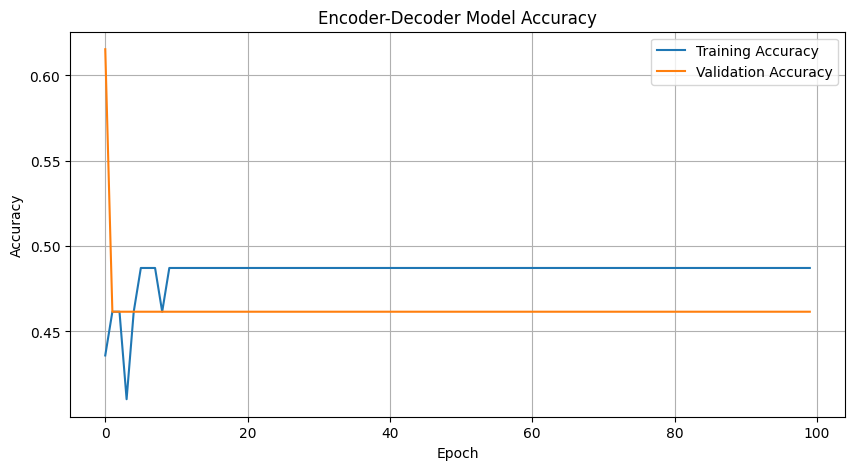

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Encoder-Decoder Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
loss, accuracy = model.evaluate(
    [encoder_input_data, decoder_input_data],
    decoder_target_data
)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4808 - loss: 0.6200
Loss: 0.6200132369995117
Accuracy: 0.48076921701431274
